# TMDB Movie Data EDA

This notebook loads movie data from the SQLite database, converts it into pandas DataFrames, and performs exploratory data analysis using tables and visualizations.


## 1. Import Libraries


In [10]:
import ast
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


## 2. Load Data From SQLite Database


In [11]:
db_path = Path('tmdb_movies.db')
conn = sqlite3.connect(db_path)
movies_df = pd.read_sql('SELECT * FROM movies', conn)
conn.close()

movies_df['genre_ids'] = movies_df['genre_ids'].apply(
    lambda value: ast.literal_eval(value) if isinstance(value, str) else value
)

movies_df['release_date'] = pd.to_datetime(movies_df['release_date'], errors='coerce')
movies_df['release_year'] = movies_df['release_date'].dt.year

movies_df.head()


,id,title,release_date,vote_average,vote_count,popularity,genre_ids,release_year
0,875828,Peaky Blinders: The Immortal Man,2026-03-05,7.400,371,354.7335,"[80, 18]",2026
1,687163,Project Hail Mary,2026-03-15,8.200,427,318.4081,"[878, 12]",2026
2,1265609,War Machine,2026-02-12,7.263,1122,309.9162,"[28, 878, 53]",2026
3,83533,Avatar: Fire and Ash,2025-12-17,7.266,1923,322.8645,"[878, 12, 14]",2025
4,1159559,Scream 7,2026-02-25,5.830,437,312.7549,"[27, 9648, 80]",2026


We loaded the data from the SQLite database and converted `genre_ids` back into Python lists, because lists are stored as text in SQL. We also created a `release_year` column to help with time-based analysis.


## 3. Basic Information


In [12]:
print('Shape of dataset:', movies_df.shape)
print('\nColumn names:')
print(movies_df.columns.tolist())
print('\nData types:')
print(movies_df.dtypes)
print('\nMissing values:')
print(movies_df.isnull().sum())
print('\nSummary statistics:')
display(movies_df.describe(include='all'))


Shape of dataset: (20, 8)

Column names:
['id', 'title', 'release_date', 'vote_average', 'vote_count', 'popularity', 'genre_ids', 'release_year']

Data types:
id                       int64
title                   object
release_date    datetime64[ns]
vote_average           float64
vote_count               int64
popularity             float64
genre_ids               object
release_year             int32
dtype: object

Missing values:
id              0
title           0
release_date    0
vote_average    0
vote_count      0
popularity      0
genre_ids       0
release_year    0
dtype: int64

Summary statistics:


,id,title,release_date,vote_average,vote_count,popularity,genre_ids,release_year
count,2.000000e+01,20,20,20.000000,20.000000,20.000000,20,20.00000
unique,NaN,20,NaN,NaN,NaN,NaN,18,NaN
top,NaN,Peaky Blinders: The Immortal Man,NaN,NaN,NaN,NaN,"[10749, 18]",NaN
freq,NaN,1,NaN,NaN,NaN,NaN,2,NaN
mean,1.140654e+06,NaN,2025-12-25 12:00:00,6.952450,580.950000,199.348290,NaN,2025.75000
min,8.353300e+04,NaN,2024-05-01 00:00:00,5.014000,3.000000,107.054500,NaN,2024.00000
25%,1.032138e+06,NaN,2026-01-16 18:00:00,6.370750,200.500000,120.981625,NaN,2026.00000
50%,1.214827e+06,NaN,2026-02-04 00:00:00,7.044000,399.000000,144.271200,NaN,2026.00000
75%,1.319024e+06,NaN,2026-02-26 18:00:00,7.602250,781.750000,310.625875,NaN,2026.00000
max,1.634301e+06,NaN,2026-03-26 00:00:00,8.200000,2316.000000,354.733500,NaN,2026.00000


This gives us a quick overview of the dataset: how many rows and columns are present, which columns are numeric, whether there are missing values, and the overall spread of values such as popularity, vote average, and vote count.


## 4. Prepare Genre Data


In [13]:
genre_map = {
    28: 'Action', 12: 'Adventure', 16: 'Animation', 35: 'Comedy',
    80: 'Crime', 99: 'Documentary', 18: 'Drama', 10751: 'Family',
    14: 'Fantasy', 36: 'History', 27: 'Horror', 10402: 'Music',
    9648: 'Mystery', 10749: 'Romance', 878: 'Science Fiction',
    10770: 'TV Movie', 53: 'Thriller', 10752: 'War', 37: 'Western'
}

genre_df = movies_df.copy().explode('genre_ids')
genre_df['genre_name'] = genre_df['genre_ids'].map(genre_map)
genre_df.head()


,id,title,release_date,vote_average,vote_count,popularity,genre_ids,release_year,genre_name
0,875828,Peaky Blinders: The Immortal Man,2026-03-05,7.400,371,354.7335,80,2026,Crime
0,875828,Peaky Blinders: The Immortal Man,2026-03-05,7.400,371,354.7335,18,2026,Drama
1,687163,Project Hail Mary,2026-03-15,8.200,427,318.4081,878,2026,Science Fiction
1,687163,Project Hail Mary,2026-03-15,8.200,427,318.4081,12,2026,Adventure
2,1265609,War Machine,2026-02-12,7.263,1122,309.9162,28,2026,Action


Since one movie can belong to multiple genres, we used `explode()` to turn each genre into its own row. This helps us count and compare genres properly in the plots below.


## 5. Plot 1: Popularity Distribution


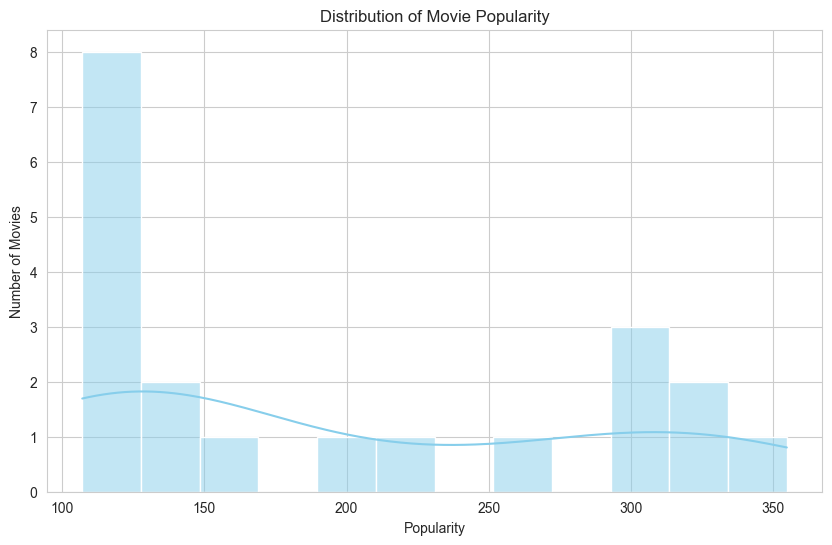

In [14]:
plt.figure()
sns.histplot(movies_df['popularity'], bins=12, kde=True, color='skyblue')
plt.title('Distribution of Movie Popularity')
plt.xlabel('Popularity')
plt.ylabel('Number of Movies')
plt.show()


This histogram shows how movie popularity values are distributed. We use it to see whether most movies have average popularity or whether a few movies are much more popular than the rest. If the graph is right-skewed, it means only a small number of movies are extremely popular.


## 6. Plot 2: Vote Average Distribution


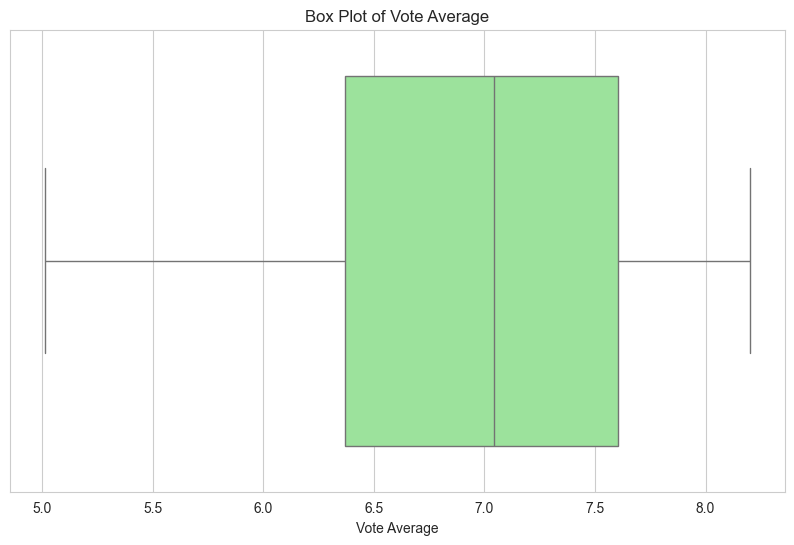

In [15]:
plt.figure()
sns.boxplot(x=movies_df['vote_average'], color='lightgreen')
plt.title('Box Plot of Vote Average')
plt.xlabel('Vote Average')
plt.show()


This box plot helps us understand the spread of movie ratings and identify outliers. From this, we can tell the median rating, the middle 50 percent of ratings, and whether a few movies have unusually low or high ratings compared to the rest.


## 7. Plot 3: Top 10 Genres


C:\Users\vemur\AppData\Local\Temp\ipykernel_14188\1126120071.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')


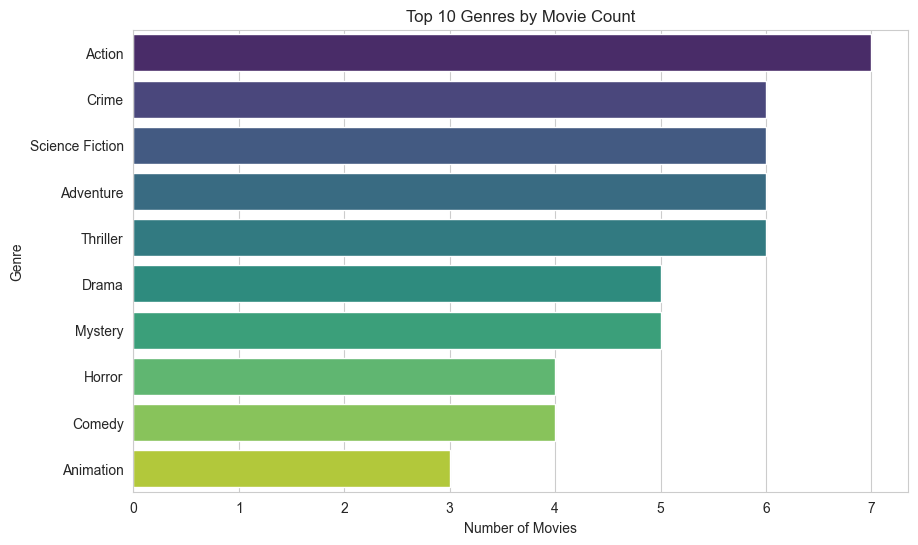

In [16]:
top_genres = genre_df['genre_name'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 10 Genres by Movie Count')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.show()


This bar chart shows which genres appear most often in the dataset. It helps us understand the composition of the fetched movie list. If one or two genres dominate, it means the current TMDB results are concentrated more heavily in those categories.


## 8. Plot 4: Top 10 Most Popular Movies


C:\Users\vemur\AppData\Local\Temp\ipykernel_14188\3486993976.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_popular, x='popularity', y='title', palette='magma')


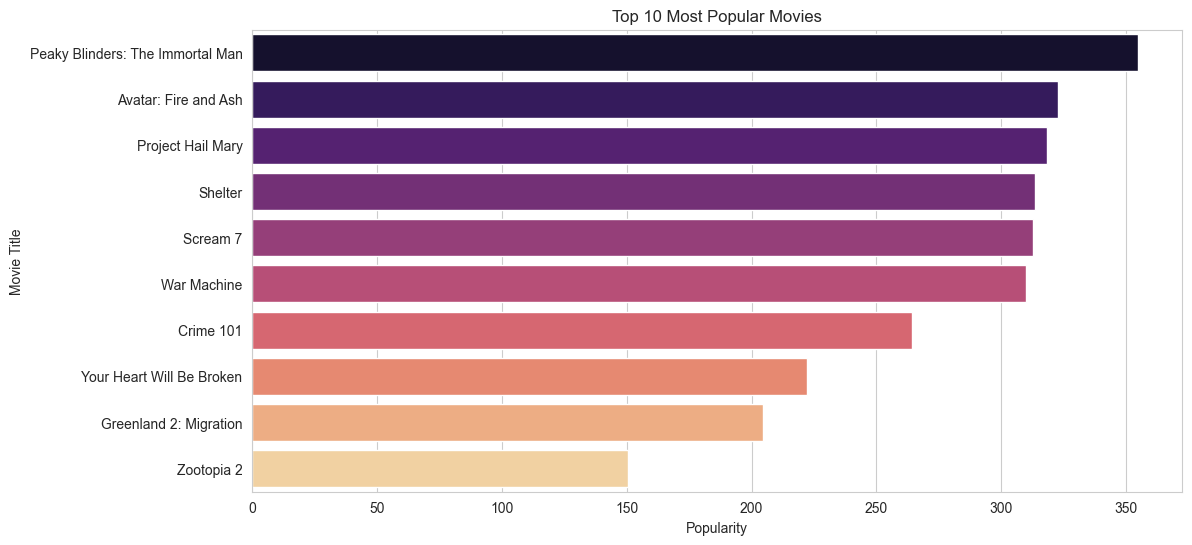

In [17]:
top_popular = movies_df.sort_values('popularity', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_popular, x='popularity', y='title', palette='magma')
plt.title('Top 10 Most Popular Movies')
plt.xlabel('Popularity')
plt.ylabel('Movie Title')
plt.show()


This plot ranks the most popular movies in the dataset. It gives a direct comparison between titles and helps us quickly identify which movies are leading in popularity and how large the gap is between the top-ranked movies and the rest.


## 9. Plot 5: Relationship Between Popularity and Vote Average


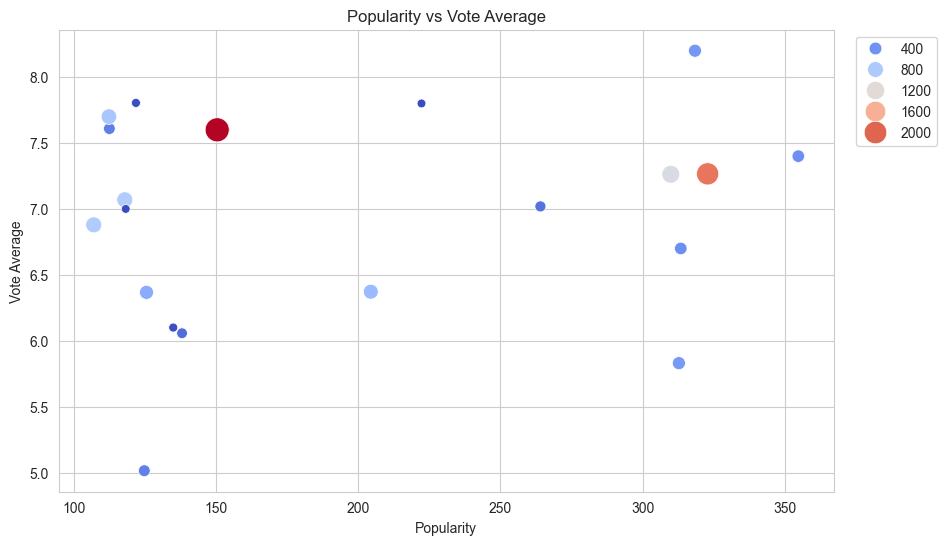

In [18]:
plt.figure()
sns.scatterplot(data=movies_df, x='popularity', y='vote_average', size='vote_count', hue='vote_count', palette='coolwarm', sizes=(40, 300))
plt.title('Popularity vs Vote Average')
plt.xlabel('Popularity')
plt.ylabel('Vote Average')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()


This scatter plot helps us understand whether more popular movies also receive better ratings. The size and color represent vote count, so we can also see whether highly rated movies are supported by many votes or only a few. This is useful for checking whether popularity and quality move together.


## 10. Plot 6: Movies Released by Year


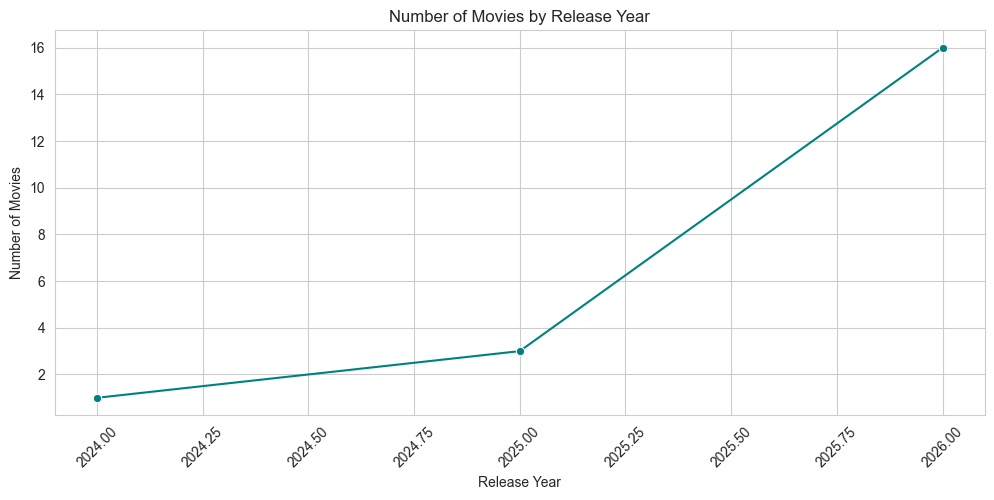

In [19]:
year_counts = movies_df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='teal')
plt.title('Number of Movies by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.show()


This line chart shows how the movies in the dataset are distributed across release years. It helps us see whether the fetched movies are mostly recent releases or spread across older years as well. Peaks in the line indicate years with more movies in the current dataset.


## 11. Plot 7: Correlation Heatmap


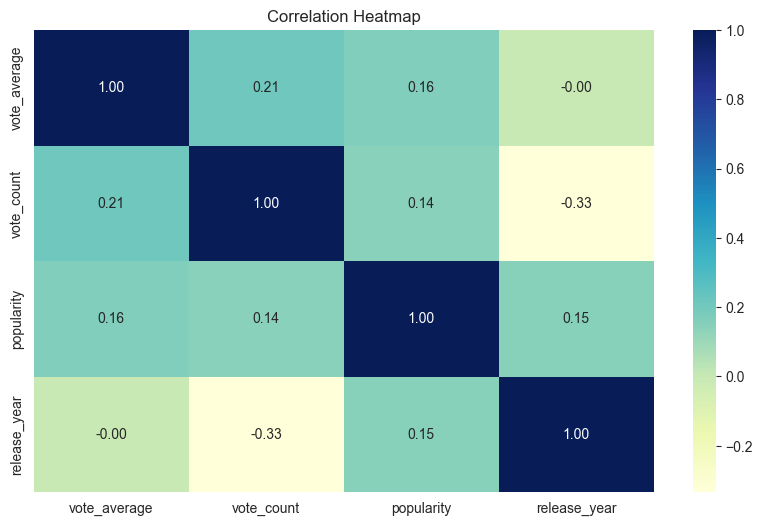

In [20]:
numeric_cols = movies_df[['vote_average', 'vote_count', 'popularity', 'release_year']]
corr_matrix = numeric_cols.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


The heatmap shows how strongly the numeric features are related to each other. A value closer to 1 means a strong positive relationship, closer to -1 means a strong negative relationship, and near 0 means little or no linear relationship. This helps us understand which variables move together.


## 12. Final Observations

- We loaded movie data from the SQLite database into a pandas DataFrame.
- We cleaned and transformed the `genre_ids` column so genre analysis becomes possible.
- We used multiple plots to study popularity, ratings, genres, release years, and relationships between variables.
- The written notes after each plot explain what the visualization shows and how to interpret it for your assignment.
